In [ ]:

import cv2
import numpy as np
from typing import List, Tuple


def load_and_split(image_path: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Carga una imagen BGR (OpenCV siempre lee en BGR), la convierte a YCrCb
    y devuelve la imagen YCrCb completa más sus 3 canales por separado.
    """
    bgr = cv2.imread(image_path)
    if bgr is None:
        raise FileNotFoundError(f"No se encontró la imagen: {image_path}")

    ycrcb = cv2.cvtColor(bgr, cv2.COLOR_BGR2YCrCb)

    Y, Cr, Cb = cv2.split(ycrcb)

    return ycrcb, Y, Cr, Cb


def merge_and_save(Y: np.ndarray, Cr: np.ndarray, Cb: np.ndarray, output_path: str) -> None:
    
    ycrcb_result = cv2.merge([Y, Cr, Cb])
    bgr_result = cv2.cvtColor(ycrcb_result, cv2.COLOR_YCrCb2BGR)
    cv2.imwrite(output_path, bgr_result)



def pad_to_multiple_of_8(channel: np.ndarray) -> np.ndarray:
 
    h, w = channel.shape
    pad_h = (8 - h % 8) % 8  # 0 si ya es múltiplo
    pad_w = (8 - w % 8) % 8
    if pad_h > 0 or pad_w > 0:
        channel = cv2.copyMakeBorder(channel, 0, pad_h, 0, pad_w,
                                    borderType=cv2.BORDER_REPLICATE)
    return channel


def iter_blocks_8x8(channel: np.ndarray):
   
    h, w = channel.shape
    for y in range(0, h, 8):
        for x in range(0, w, 8):
            yield y, x, channel[y:y+8, x:x+8]


def process_channel(channel: np.ndarray,
                    block_fn) -> np.ndarray:
    
    channel_f = channel.astype(np.float64)
    result = np.zeros_like(channel_f)

    for y, x, block_np in iter_blocks_8x8(channel_f):
        block_list = block_np.tolist()

        # Aquí irá: freqs = to_frequencies(block_list)
        # Luego la compresión/esteganografía
        # Luego: block_procesado = from_frequencies(freqs)
        block_procesado = block_fn(block_list)

        result[y:y+8, x:x+8] = np.array(block_procesado)

    return np.clip(result, 0, 255).astype(np.uint8)


#  Ejemplo de uso (bloque_fn identidad, sin tocar nada aún) 

def identity_block(block: List[List[float]]) -> List[List[float]]:
    
    from dct import to_frequencies, from_frequencies
    freqs = to_frequencies(block)
    # Aquí vendrá la compresión y el embedding del mensaje
    return from_frequencies(freqs)


if __name__ == "__main__":
    ycrcb, Y, Cr, Cb = load_and_split("foto.jpeg")

    h_orig, w_orig = Y.shape

    Y_pad  = pad_to_multiple_of_8(Y)
    Cr_pad = pad_to_multiple_of_8(Cr)
    Cb_pad = pad_to_multiple_of_8(Cb)

    # Procesar cada canal con su lógica (por ahora identidad)
    Y_out  = process_channel(Y_pad,  identity_block)[:h_orig, :w_orig]
    Cr_out = process_channel(Cr_pad, identity_block)[:h_orig, :w_orig]
    Cb_out = process_channel(Cb_pad, identity_block)[:h_orig, :w_orig]

    merge_and_save(Y_out, Cr_out, Cb_out, "foto_comprimida.jpg")
    print("Hecho.")

Hecho.


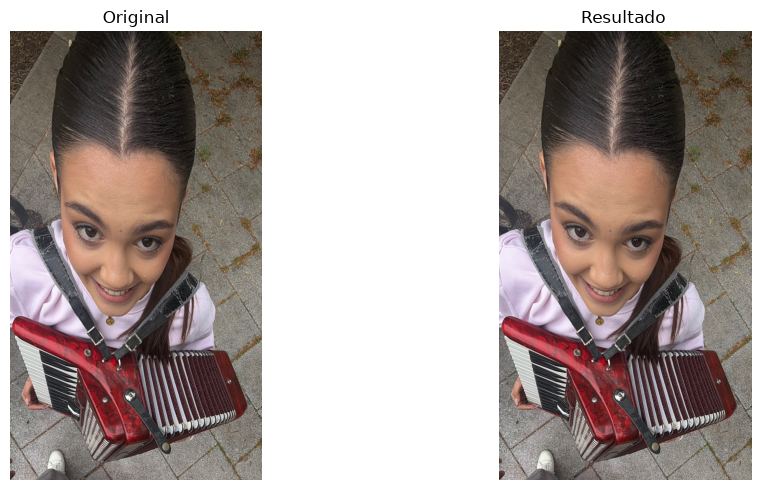

In [10]:
import matplotlib.pyplot as plt

original = cv2.imread("foto.jpeg")
resultado = cv2.imread("foto_comprimida.jpg")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(cv2.cvtColor(original, cv2.COLOR_BGR2RGB))
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
axes[1].set_title("Resultado ")
axes[1].axis("off")

plt.tight_layout()
plt.show()